***Objective***

*Analyze misinformation patterns, evaluate fact-check coverage, and explore baseline machine learning for fake news classification.*

In [19]:
# ---------------------
#   Import Libraries
# ---------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [51]:
# -------------------
#   Load Datasets
# -------------------

misinfo = pd.read_csv("/content/misinformation_dataset1.csv", encoding='latin1')
factcheck = pd.read_csv("/content/fact_check_1dataset.csv", encoding='latin1')

**SQL Analysis**

In [14]:
#--------------
#  Load Data
#--------------

import sqlite3

conn =  sqlite3.connect("misinfo.db")

misinfo.to_sql("misinformation",conn,if_exists = "replace",index=False)
factcheck.to_sql("factcheck",conn,if_exists = "replace",index=False)

102

*View Data*

In [15]:
pd.read_sql ("SELECT * from misinformation LIMIT 10",conn)

,content_id,title,text,topic,label,source_name,source_url,date_published,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,is_fact_checked
0,101.0,"""India's elevator industry pushes 'One nation,...","""Indias elevator industry pushes One Nation,...",Politics,FALSE,The Hindu,https://www.thehindu.com/business/Industry/ind...,21-01-2026,None,None,None,None,1
1,102.0,"""AI 'slop' is transforming social media - and ...","""The image showed two emaciated South Asian ch...",AI,MISLEADING,BBC News,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,None,None,None,None,1
2,103.0,"""Social media's 'third phase'""","""In October, Meta CEO Mark Zuckerberg announce...",AI,MISLEADING,BBC News,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,None,None,None,None,1
3,104.0,"""Giant monsters and deadly belly parasites""","""Théodore influence on X, he complained to You...",AI,FALSE,BBC News,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,None,None,None,None,1
4,105.0,"""Aspirin can reduce the risk of cancer - and w...","""A 4,000-year-old pain drug has been found to ...",Health,MISLEADING,BBC News,https://www.bbc.com/future/article/20260420-ca...,21-04-2026,None,None,None,None,1
5,106.0,"""Bird flu vaccine trial against potential pand...","""The vaccine targets H5N1 flu, which has devas...",Health,TRUE,BBC NEWS,https://www.bbc.com/news/articles/cy41z0yj8mjo,22-04-2026,None,None,None,None,1
6,107.0,"""Climate change is supercharging pollen and ma...","""Seasonal allergy sufferers face longer, stron...",Health,TRUE,BBC News,https://www.bbc.com/future/article/20250410-ho...,12-04-2025,None,None,None,None,1
7,108.0,"""Meta to track workers' clicks and keystrokes ...","""Meta will start tracking the way employees wo...",Technology,MISLEADING,BBC News,https://www.bbc.com/news/articles/cvglyklz49jo,22-04-2026,None,None,None,None,1
8,109.0,"""Tech CEOs suddenly love blaming AI for mass j...","""Sweeping job cuts at Big Tech have become ann...",Technology,MISLEADING,BBC News,https://www.bbc.com/news/articles/cde5y2x51y8o,29-03-2026,None,None,None,None,1
9,110.0,"""Amazon shares fall as it joins Big Tech AI sp...","""Amazon announced plans to invest $200bn in AI...",Technology,TRUE,BBC News,https://www.bbc.com/news/articles/c150e144we3o,06-02-2026,None,None,None,None,1


*Most Common labels*

In [16]:
pd.read_sql("""
SELECT label, COUNT(*) as count
FROM misinformation
GROUP BY label
ORDER BY count DESC
""", conn)

,label,count
0,TRUE,51
1,MISLEADING,29
2,FALSE,20
3,None,1


*Top topics*

In [17]:
pd.read_sql("""
SELECT topic, COUNT(*) as count
FROM misinformation
GROUP BY topic
ORDER BY count DESC
""", conn)

,topic,count
0,AI,43
1,Politics,30
2,Technology,18
3,Health,6
4,Education,3
5,None,1


*Fact-check coverage check*

In [18]:
pd.read_sql("""
SELECT COUNT(DISTINCT m.content_id) as total_misinfo,
       COUNT(DISTINCT f.content_id) as fact_checked_overlap
FROM misinformation m
LEFT JOIN factcheck f
ON m.content_id = f.content_id
""", conn)

,total_misinfo,fact_checked_overlap
0,100,100


SQL was used to perform structured querying and aggregation of misinformation and fact-check datasets. This helped validate insights obtained from Python-based analysis and enabled efficient data filtering and grouping operations.

In [4]:
# --------------------
# Misinformation Dataset Feature Names (Columns Overview)
# --------------------

misinfo.columns

Index(['content_id', 'title', 'text', 'topic', 'label', 'source_name',
       'source_url', 'date_published', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')

In [38]:
# --------------------
# Fact-Check Dataset Feature Names (Columns Overview)
# --------------------

factcheck.columns

Index(['content_id', 'claim_reviewed', 'fact_check_rating', 'corrected_fact',
       'evidence_source', 'evidence_url', 'fact_checker', 'review_date',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'],
      dtype='object')

In [6]:
# ------------------------------------------------------------------
#    Initial Inspection of Misinformation Data (First 3 Records)
# ------------------------------------------------------------------
misinfo.head(3)

,content_id,title,text,topic,label,source_name,source_url,date_published,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,101.0,"""India's elevator industry pushes 'One nation,...","""Indias elevator industry pushes One Nation,...",Politics,FALSE,The Hindu,https://www.thehindu.com/business/Industry/ind...,21-01-2026,NaN,NaN,NaN,NaN
1,102.0,"""AI 'slop' is transforming social media - and ...","""The image showed two emaciated South Asian ch...",AI,MISLEADING,BBC News,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,NaN,NaN,NaN,NaN
2,103.0,"""Social media's 'third phase'""","""In October, Meta CEO Mark Zuckerberg announce...",AI,MISLEADING,BBC News,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,NaN,NaN,NaN,NaN


In [10]:
# ------------------------------------------------------------------
#    Initial Inspection of Fact-check Data (First 3 Records)
# ------------------------------------------------------------------
factcheck.head(3)

,content_id,claim_reviewed,fact_check_rating,corrected_fact,evidence_source,evidence_url,fact_checker,review_date,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,101.0,Elevator industry proposes unified national re...,TRUE,Proposal exists but is still under discussion ...,The Hindu,https://www.thehindu.com,BBC Fact Check,21-01-2026,NaN,NaN,NaN
1,102.0,AI-generated disturbing images spreading online,MISLEADING,Images exist but context is misrepresented as ...,BBC News,https://www.bbc.com/news,BBC Fact Check,04-02-2026,NaN,NaN,NaN
2,103.0,Social media has entered AI-driven third phase,TRUE,Experts agree AI is reshaping social platforms,BBC News,https://www.bbc.com/news,BBC Fact Check,04-02-2026,NaN,NaN,NaN


In [12]:
# -------------------------------------------------------------
#   Checking Size of Misinformation and Fact-Check Datasets
# -------------------------------------------------------------

print("Misinformation dataset size:",misinfo.size)
print("Fact-check dataset size:",factcheck.size)

Misinformation dataset size: 1212
Fact-check dataset size: 1122


In [19]:
# -----------------------------------------------------------------------
#   Data Type Inspection of Misinformation Dataset & Fact-Check Datasets
# -----------------------------------------------------------------------

print("Misinformation dataset datatype:",misinfo.dtypes)
print("\nFact-check dataset datatype:",factcheck.dtypes)

Misinformation dataset datatype: content_id        float64
title              object
text               object
topic              object
label              object
source_name        object
source_url         object
date_published     object
Unnamed: 8        float64
Unnamed: 9         object
Unnamed: 10       float64
Unnamed: 11        object
dtype: object

Fact-check dataset datatype: content_id           float64
claim_reviewed        object
fact_check_rating     object
corrected_fact        object
evidence_source       object
evidence_url          object
fact_checker          object
review_date           object
Unnamed: 8           float64
Unnamed: 9            object
Unnamed: 10           object
dtype: object


In [20]:
# --------------------------------------------------------------
#   Understanding Misinformation Dataset Structure using info()
# --------------------------------------------------------------
misinfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   content_id      100 non-null    float64
 1   title           100 non-null    object 
 2   text            100 non-null    object 
 3   topic           100 non-null    object 
 4   label           100 non-null    object 
 5   source_name     100 non-null    object 
 6   source_url      101 non-null    object 
 7   date_published  100 non-null    object 
 8   Unnamed: 8      0 non-null      float64
 9   Unnamed: 9      1 non-null      object 
 10  Unnamed: 10     0 non-null      float64
 11  Unnamed: 11     1 non-null      object 
dtypes: float64(3), object(9)
memory usage: 9.6+ KB


In [21]:
# -----------------------------------------------------------
#   Understanding Fact-check Dataset Structure using info()
# -----------------------------------------------------------
factcheck.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   content_id         100 non-null    float64
 1   claim_reviewed     100 non-null    object 
 2   fact_check_rating  100 non-null    object 
 3   corrected_fact     101 non-null    object 
 4   evidence_source    100 non-null    object 
 5   evidence_url       100 non-null    object 
 6   fact_checker       100 non-null    object 
 7   review_date        100 non-null    object 
 8   Unnamed: 8         0 non-null      float64
 9   Unnamed: 9         1 non-null      object 
 10  Unnamed: 10        1 non-null      object 
dtypes: float64(2), object(9)
memory usage: 8.9+ KB


In [27]:
# ------------------------------
#    Missing Values Analysis
# ------------------------------

misinfo.isnull().sum()
factcheck.isnull().sum()

,0
content_id,2
claim_reviewed,2
fact_check_rating,2
corrected_fact,1
evidence_source,2
evidence_url,2
fact_checker,2
review_date,2
Unnamed: 8,102
Unnamed: 9,101


In [33]:
# -------------------------
# Duplicate Records Check
# -------------------------

misinfo.duplicated().sum()
factcheck.duplicated().sum()

np.int64(0)

In [39]:
# --------------------
# Statistical Summary of Dataset
# --------------------

misinfo.describe()

,content_id,Unnamed: 8,Unnamed: 10
count,100.000000,0.0,0.0
mean,150.500000,NaN,NaN
std,29.011492,NaN,NaN
min,101.000000,NaN,NaN
25%,125.750000,NaN,NaN
50%,150.500000,NaN,NaN
75%,175.250000,NaN,NaN
max,200.000000,NaN,NaN


In [40]:
factcheck.describe()

,content_id,Unnamed: 8
count,100.000000,0.0
mean,150.500000,NaN
std,29.011492,NaN
min,101.000000,NaN
25%,125.750000,NaN
50%,150.500000,NaN
75%,175.250000,NaN
max,200.000000,NaN


In [ ]:
# # -----------------------------------------------------------
#  Column-wise Insights using Mode, Unique, and Frequency Analysis
# --------------------------------------------------------------

In [54]:
# -----------------------------------------
# Frequency Distribution of Column Values
# -----------------------------------------

misinfo["topic"].value_counts(ascending=True).head(100)

,count
topic,
Education,3
Health,6
Technology,18
Politics,30
AI,43


In [53]:
factcheck["evidence_source"].value_counts(ascending=True).head(100)

,count
evidence_source,
BBC Future,3
Indian Express,15
The Hindu,16
Reuters,30
BBC News,36


In [62]:
# --------------------
# Count of Unique Values in Each Column
# --------------------
misinfo.head()
misinfo["topic"].nunique()

5

In [63]:
factcheck["fact_check_rating"].nunique()

3

In [69]:
# --------------------
# Unique Values Present in Column
# --------------------
misinfo["source_name"].unique()

array(['The Hindu', 'BBC News', 'BBC NEWS', 'Reuters', 'IndianExpress',
       nan], dtype=object)

In [71]:
factcheck["fact_checker"].unique()

array(['BBC Fact Check', 'WHO Fact Check', 'Reuters Fact Check',
       'OpenAI Review', 'Adobe Review', 'AI Research', 'Policy Review',
       'Science Review', 'EU Review', 'ILO Review', 'Security Review',
       'Government Review', 'Tech Review', 'AI Review',
       'Education Review', 'Health Review', 'Investigation',
       'Political Review', 'Fact Check', 'Finance Review',
       'Business Review', 'Media Review', nan], dtype=object)

In [73]:
# --------------------
# Misinformation dataset Mode()
# --------------------

misinfo["label"].mode()

,label
0,TRUE


In [74]:
factcheck["evidence_source"].mode()

,evidence_source
0,BBC News


In [ ]:
# # --------------------------------------------
# EDA - Misinformation Dataset Analysis
# --------------------------------------------

**EDA - Misinformation and FactCheck Dataset Analysis**

***Misinformation Dataset***

In [5]:
# Q1: What are the most common topics in the misinformation dataset?
misinfo["topic"].value_counts()

,count
topic,
AI,43
Politics,30
Technology,18
Health,6
Education,3


/tmp/ipykernel_4471/782967394.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="topic", data=misinfo,color="green",palette="viridis")


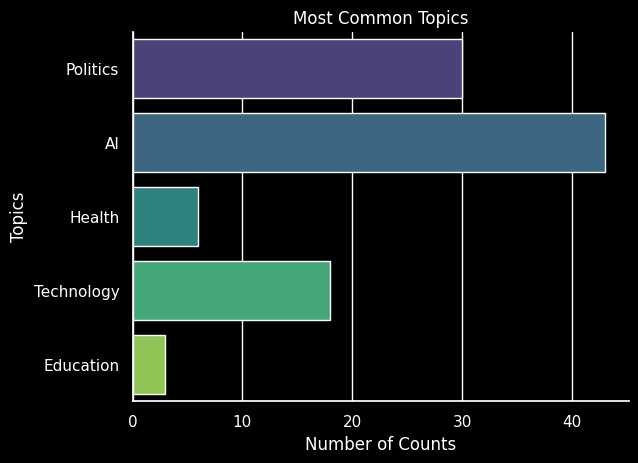

In [28]:
sns.countplot(y="topic",
              data=misinfo,
              color="green",

              palette="viridis")
sns.set_theme(style="darkgrid")
sns.despine()

plt.xlabel("Number of Counts")
plt.ylabel("Topics")
plt.title("Most Common Topics")
plt.show()

The topic distribution shows that misinformation is unevenly distributed across subjects, with AI appearing substantially more often than others, indicating concentration in specific areas of concern.

In [5]:
#---------------------
#     Filtering
#---------------------

misinfo["label"] = (
    misinfo["label"]
      .str.strip()
      .str.upper()
)

print(misinfo["label"].unique())

misinfo["label"].value_counts(normalize=True)

misinfo.to_csv("misinformation_cleaned.csv", index=False)

['FALSE' 'MISLEADING' 'TRUE' nan]


In [45]:
misinfo["source_name"] = (
    misinfo["source_name"]
      .str.strip()
      .str.upper()
)

print(misinfo["source_name"].unique())

misinfo["source_name"].value_counts(normalize=True)

misinfo.to_csv("misinformation_cleaned.csv", index=False)

['THE HINDU' 'BBC NEWS' 'REUTERS' 'INDIANEXPRESS' nan]


In [47]:
misinfo =  pd.read_csv("misinformation_cleaned.csv")
misinfo

,content_id,title,text,topic,label,source_name,source_url,date_published,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,101.0,"""India's elevator industry pushes 'One nation,...","""Indias elevator industry pushes One Nation,...",Politics,FALSE,THE HINDU,https://www.thehindu.com/business/Industry/ind...,21-01-2026,NaN,NaN,NaN,NaN
1,102.0,"""AI 'slop' is transforming social media - and ...","""The image showed two emaciated South Asian ch...",AI,MISLEADING,BBC NEWS,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,NaN,NaN,NaN,NaN
2,103.0,"""Social media's 'third phase'""","""In October, Meta CEO Mark Zuckerberg announce...",AI,MISLEADING,BBC NEWS,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,NaN,NaN,NaN,NaN
3,104.0,"""Giant monsters and deadly belly parasites""","""Théodore influence on X, he complained to You...",AI,FALSE,BBC NEWS,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,NaN,NaN,NaN,NaN
4,105.0,"""Aspirin can reduce the risk of cancer - and w...","""A 4,000-year-old pain drug has been found to ...",Health,MISLEADING,BBC NEWS,https://www.bbc.com/future/article/20260420-ca...,21-04-2026,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
96,197.0,"""AI hiring tool rejects all human recruiters""","""Headline exaggerated automation scope.""",Technology,MISLEADING,INDIANEXPRESS,https://indianexpress.com/,23-04-2026,NaN,NaN,NaN,NaN
97,198.0,"""Fake deepfake arrest video triggers panic onl...","""Manipulated clip was debunked.""",Politics,FALSE,BBC NEWS,https://www.bbc.com/news,23-04-2026,NaN,NaN,NaN,NaN
98,199.0,"""Major platform expands provenance labels glob...","""Rollout announcement supported by reporting.""",Technology,TRUE,REUTERS,https://www.reuters.com/technology/,23-04-2026,NaN,NaN,NaN,NaN
99,200.0,"""Experts warn election misinformation may surg...","""Broad warning supported though predictive cer...",AI,MISLEADING,BBC NEWS,https://www.bbc.com/news,23-04-2026,NaN,,NaN,NaN


In [35]:
# Q2: Are some sources consistently more false vs misleading vs true?

misleading = misinfo[misinfo["label"] == "MISLEADING"]["source_name"].value_counts()
misleading

true = misinfo[misinfo["label"] == "TRUE"]["source_name"].value_counts()
true

false = misinfo[misinfo["label"] == "FALSE"]["source_name"].value_counts()
false

comparison = pd.concat([
    misleading,
    true,
    false
], axis=1)

comparison.columns = ["misleading", "true", "false"]
comparison = comparison.fillna(0)
comparison = comparison.sort_values(by="misleading", ascending=False)
comparison

,misleading,true,false
source_name,,,
BBC News,14,16,9
Indianexpress,6,5,3
The Hindu,6,4,6
Reuters,2,26,2


In [33]:
misinfo["source_name"] = misinfo["source_name"].str.strip().str.upper()
misinfo["source_name"] = misinfo["source_name"].str.strip().str.title()
misinfo["source_name"] = misinfo["source_name"].replace({
    "Bbc News":"BBC News"
})
misinfo["source_name"].unique()
misinfo

,content_id,title,text,topic,label,source_name,source_url,date_published,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,101.0,"""India's elevator industry pushes 'One nation,...","""Indias elevator industry pushes One Nation,...",Politics,FALSE,The Hindu,https://www.thehindu.com/business/Industry/ind...,21-01-2026,NaN,NaN,NaN,NaN
1,102.0,"""AI 'slop' is transforming social media - and ...","""The image showed two emaciated South Asian ch...",AI,MISLEADING,BBC News,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,NaN,NaN,NaN,NaN
2,103.0,"""Social media's 'third phase'""","""In October, Meta CEO Mark Zuckerberg announce...",AI,MISLEADING,BBC News,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,NaN,NaN,NaN,NaN
3,104.0,"""Giant monsters and deadly belly parasites""","""Théodore influence on X, he complained to You...",AI,FALSE,BBC News,https://www.bbc.com/news/articles/c9wx2dz2v44o,04-02-2026,NaN,NaN,NaN,NaN
4,105.0,"""Aspirin can reduce the risk of cancer - and w...","""A 4,000-year-old pain drug has been found to ...",Health,MISLEADING,BBC News,https://www.bbc.com/future/article/20260420-ca...,21-04-2026,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
96,197.0,"""AI hiring tool rejects all human recruiters""","""Headline exaggerated automation scope.""",Technology,MISLEADING,Indianexpress,https://indianexpress.com/,23-04-2026,NaN,NaN,NaN,NaN
97,198.0,"""Fake deepfake arrest video triggers panic onl...","""Manipulated clip was debunked.""",Politics,FALSE,BBC News,https://www.bbc.com/news,23-04-2026,NaN,NaN,NaN,NaN
98,199.0,"""Major platform expands provenance labels glob...","""Rollout announcement supported by reporting.""",Technology,TRUE,Reuters,https://www.reuters.com/technology/,23-04-2026,NaN,NaN,NaN,NaN
99,200.0,"""Experts warn election misinformation may surg...","""Broad warning supported though predictive cer...",AI,MISLEADING,BBC News,https://www.bbc.com/news,23-04-2026,NaN,,NaN,NaN


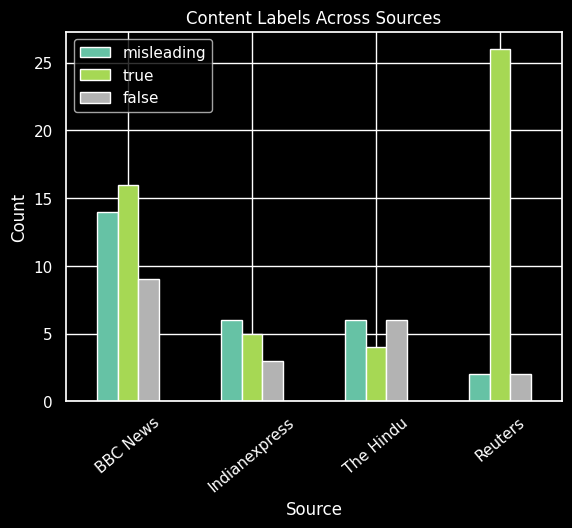

In [36]:
plt.style.use("dark_background")
comparison.plot(kind="bar",colormap="Set2")

plt.legend(loc="upper left")
plt.title("Content Labels Across Sources")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=40)
plt.show()

The graph shows that misinformation labels are not evenly distributed across sources. Some publishers have consistently higher misleading or false content counts, suggesting source-level differences in misinformation behavior.

In [48]:
# Q3:What is the overall ratio of TRUE vs FALSE vs MISLEADING content?
misinfo.head()
misinfo["label"].value_counts(normalize=True)

,proportion
label,
TRUE,0.51
MISLEADING,0.29
FALSE,0.20


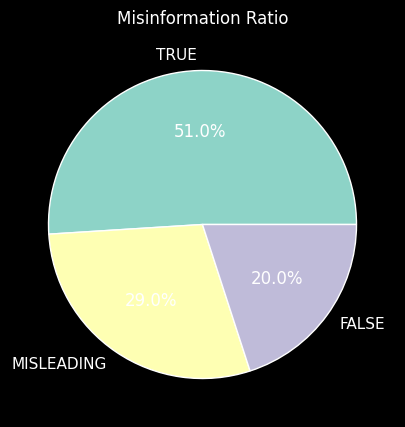

In [55]:
misinfo["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,5)
)
plt.title("Misinformation Ratio")
plt.ylabel("")
plt.show()

The pie chart shows the proportion of TRUE, FALSE, and MISLEADING content in the dataset. A larger share of false/misleading labels suggests misinformation is prominent in the collected articles.

In [61]:
# Q4: Which sources have the highest reliability score (% TRUE articles per source)?

true = misinfo[misinfo["label"]=="TRUE"]["source_name"].value_counts(normalize=True)
true.sort_values(ascending=True)
true

,proportion
source_name,
REUTERS,0.509804
BBC NEWS,0.313725
INDIANEXPRESS,0.098039
THE HINDU,0.078431


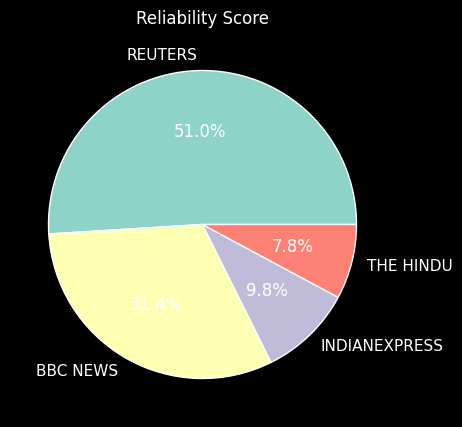

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

true = misinfo[misinfo["label"]=="TRUE"]["source_name"].value_counts().plot(
    kind="pie"
    ,autopct="%1.1f%%"
    ,figsize=(6,5)
)

plt.title("Reliability Score")
plt.ylabel("")
plt.show()



Reuters and BBC News contribute the highest proportion of true content, which may indicate stronger emphasis on verified reporting compared with other sources.

***Fact-check Dataset***

In [65]:
# Q1 : Which fact-checkers review the highest number of claims?
factcheck.head()
factcheck["fact_checker"].value_counts(normalize=True)

,proportion
fact_checker,
BBC Fact Check,0.20
Policy Review,0.15
Tech Review,0.12
Reuters Fact Check,0.12
Science Review,0.05
Security Review,0.05
Political Review,0.05
AI Review,0.04
Fact Check,0.04


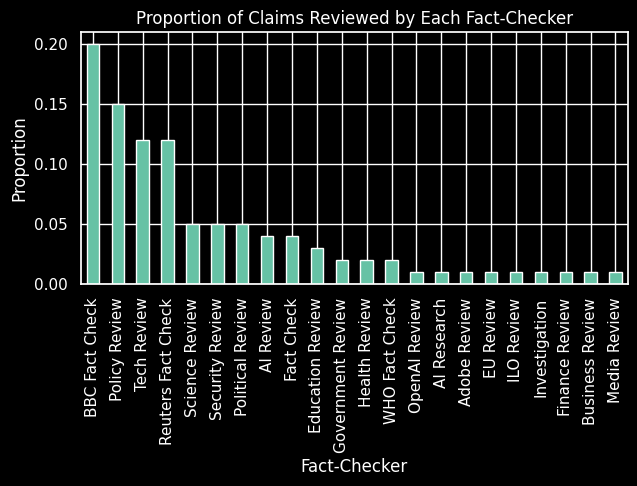

In [77]:
factcheck["fact_checker"].value_counts(normalize=True).plot(
    kind="bar",
    colormap="Set2")


plt.tight_layout()

plt.title("Proportion of Claims Reviewed by Each Fact-Checker")
plt.xlabel("Fact-Checker")
plt.ylabel("Proportion")
plt.show()

BBC Fact Check accounts for the highest proportion of reviewed claims, suggesting it plays a major role in verification within this dataset.

In [91]:
# Q2: Which sources are most frequently flagged as false and misleading in fact-checks?
misleading = factcheck[factcheck["fact_check_rating"] == "MISLEADING"]["evidence_source"].value_counts()

false = factcheck[factcheck["fact_check_rating"]=="FALSE"]["evidence_source"].value_counts()

comparison = pd.concat([misleading,false],axis=1)
comparison.columns = ["misleading","false"]
comparison = comparison.fillna(0)

comparison

,misleading,false
evidence_source,,
BBC News,9,9.0
Indian Express,6,3.0
The Hindu,4,6.0
Reuters,2,4.0
BBC Future,2,0.0


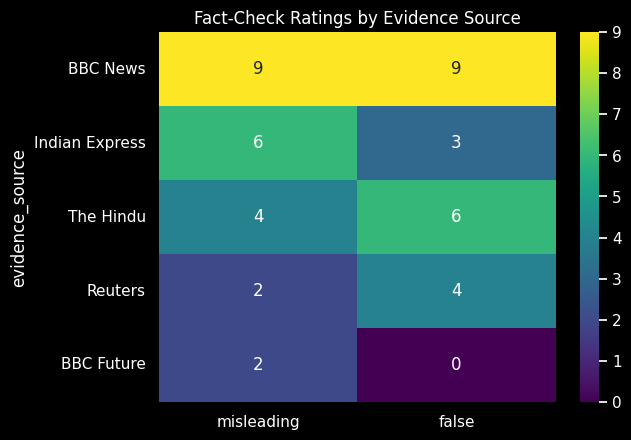

In [92]:
sns.heatmap(comparison,
            annot=True,
            cmap="viridis")

plt.title("Fact-Check Ratings by Evidence Source")
plt.show()

BBC News contributes the highest support for both misleading and false claim reviews, suggesting it is a major evidence source used across multiple fact-check outcomes. This may indicate strong reliance on BBC reporting during verification.

In [11]:
# Q3: Which evidence sources are used most frequently in verification?

factcheck["evidence_source"].value_counts(normalize=True)

,proportion
evidence_source,
BBC News,0.36
Reuters,0.30
The Hindu,0.16
Indian Express,0.15
BBC Future,0.03


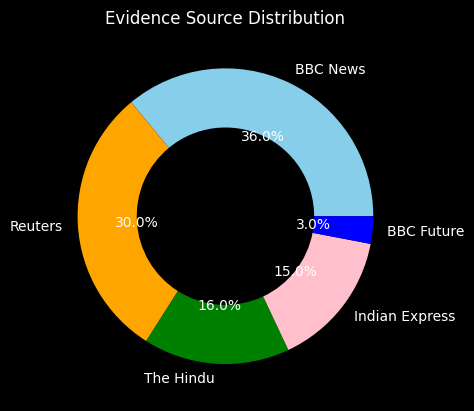

In [24]:
counts = factcheck["evidence_source"].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4},
    colors=["skyblue","orange","green","pink","blue"]
)

plt.style.use("dark_background")

plt.title("Evidence Source Distribution")
plt.show()

BBC News is the most frequently used evidence source, suggesting fact-checkers rely heavily on it for verification compared with other sources.

In [31]:
# Q4: Do evidence sources differ across false vs misleading claims?

table = factcheck.groupby(
    ["evidence_source",
     "fact_check_rating"]
).size().unstack(fill_value=0)

table


fact_check_rating,FALSE,MISLEADING,TRUE
evidence_source,,,
BBC Future,0,2,1
BBC News,9,9,18
Indian Express,3,6,6
Reuters,4,2,24
The Hindu,6,4,6


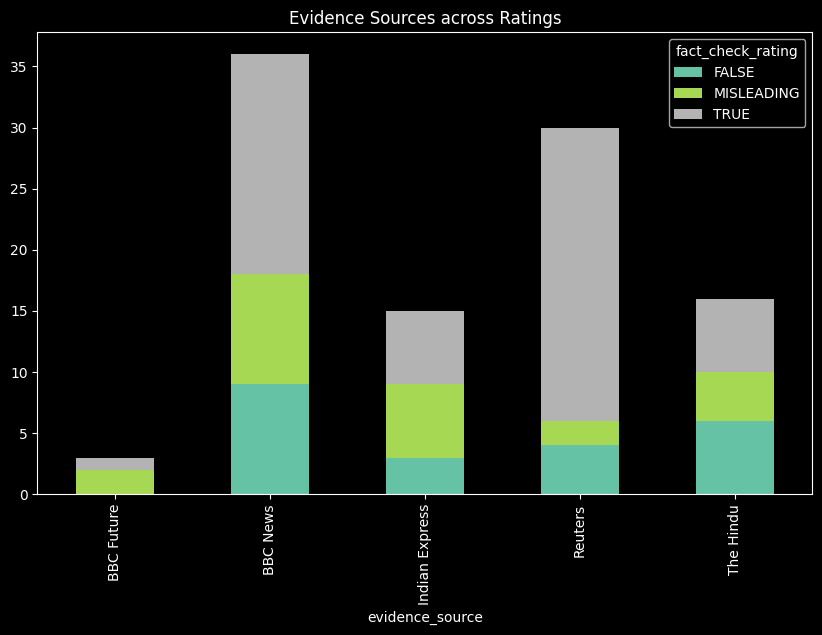

In [32]:
table.plot(
    kind="bar",
    stacked=True,
    colormap="Set2",
    figsize=(10,6)
)

plt.title("Evidence Sources across Ratings")
plt.show()

“Evidence sources are not uniformly distributed across false and misleading claims, with some sources appearing more strongly associated with specific rating types.”

***CROSS-DATASET ANALYSIS***

In [6]:
# -----------------------------------
#   Check Common Content IDs
#------------------------------------

common_ids = set(misinfo["content_id"]).intersection(set(factcheck["content_id"]))

print("Total Misinformation Records:", len(misinfo))
print("Total Fact-check Records:", len(factcheck))
print("Common Content IDs:", len(common_ids))

Total Misinformation Records: 101
Total Fact-check Records: 102
Common Content IDs: 100


In [7]:
#---------------------------------
# Create Fact-Check Coverage Flag
#---------------------------------
coverage_flag = misinfo["is_fact_checked"] = misinfo["content_id"].isin(common_ids)
coverage_flag

,content_id
0,True
1,True
2,True
3,True
4,True
...,...
96,True
97,True
98,True
99,True


In [8]:
#------------------------
#  Coverage Breakdown
#------------------------
coverage_counts = misinfo["is_fact_checked"].value_counts()

print(coverage_counts)

is_fact_checked
True     100
False      1
Name: count, dtype: int64


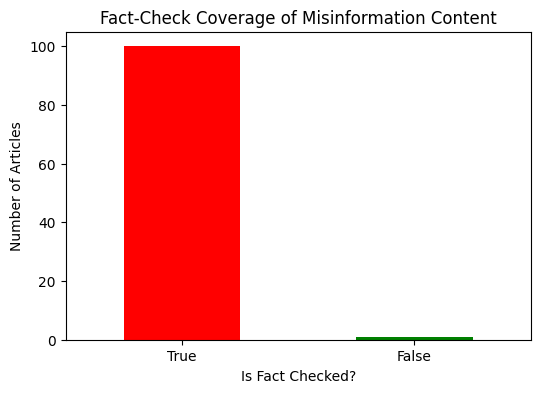

In [9]:
#--------------------------------------
# Visualization: Fact-Check Coverage
#--------------------------------------
plt.figure(figsize=(6,4))

coverage_counts.plot(
    kind="bar",
    color=["red", "green"]
)

plt.title("Fact-Check Coverage of Misinformation Content")
plt.xlabel("Is Fact Checked?")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.show()

In [10]:
# -----------------------
#   Coverage Percentage
# -----------------------
coverage_percent = misinfo["is_fact_checked"].mean() * 100

print(f"Fact-Check Coverage Percentage: {coverage_percent:.2f}%")

Fact-Check Coverage Percentage: 99.01%


***ML MODEL: Fake News Classification***

*1.* *Prepare* *Dataset*

In [24]:
misinfo = misinfo.copy()
misinfo =  misinfo[["text","label"]].dropna()
misinfo

,text,label
0,"""Indias elevator industry pushes One Nation,...",FALSE
1,"""The image showed two emaciated South Asian ch...",MISLEADING
2,"""In October, Meta CEO Mark Zuckerberg announce...",MISLEADING
3,"""Théodore influence on X, he complained to You...",FALSE
4,"""A 4,000-year-old pain drug has been found to ...",MISLEADING
...,...,...
95,"""Study suggested possible influence risks.""",TRUE
96,"""Headline exaggerated automation scope.""",MISLEADING
97,"""Manipulated clip was debunked.""",FALSE
98,"""Rollout announcement supported by reporting.""",TRUE


*2. Convert Labels to Numbers*

In [56]:
misinfo = pd.read_csv("/content/misinformation_cleaned.csv")  # reload original dataset
misinfo["label"].value_counts(dropna=False)

,count
label,
TRUE,51
MISLEADING,29
FALSE,20
NaN,1


In [57]:
misinfo = misinfo.dropna(subset=["label"])
misinfo["label"] = misinfo["label"].map({
    "TRUE": 0,
    "FALSE": 1,
    "MISLEADING": 2
})
misinfo["label"].value_counts()

,count
label,
0,51
2,29
1,20


In [58]:
misinfo["label"].unique()

array([1, 2, 0])

*3. Split Data*

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    misinfo["text"],
    misinfo["label"],
    test_size=0.2,
    random_state=42
)

X_train, X_test, y_train, y_test

(55    "Claim overstated preliminary research findings."
 88    "Reports suggest rising synthetic low quality ...
 26    "SpaceX says unproven AI space data centres ma...
 42    "Policymakers considered disclosure norms for ...
 69    "Researchers found signs of coordinated amplif...
                             ...                        
 60      "Image used out-of-context automation footage."
 71    "Company announced algorithm changes targeting...
 14    "SK Hynix reported record quarterly profit wit...
 92                  "Claim fabricated and unsupported."
 51    "Officials debated stronger enforcement mechan...
 Name: text, Length: 80, dtype: object,
 83         "Claim ignores significant system failures."
 53    "Manipulated video falsely showed a candidate ...
 70        "Viral claim overstated disputed technology."
 45    " Critics raised concerns about privacy implic...
 44        "New rural welfare measures were announced. "
 39    " Lawmakers debated expanded digital safe

*4. Convert Text → Numbers*

In [73]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(X_train_vec.shape)
print(X_test_vec.shape)

(80, 427)
(20, 427)


*5. Train Model*

In [64]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

*6. Predictions*

In [68]:
y_pred = model.predict(X_test_vec)
y_test

,label
83,1
53,1
70,1
45,0
44,0
39,0
22,2
80,1
10,0
0,1


*7. Accuracy*

In [69]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6


*8.Full Report*

In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.90      0.75        10
           1       1.00      0.33      0.50         6
           2       0.25      0.25      0.25         4

    accuracy                           0.60        20
   macro avg       0.63      0.49      0.50        20
weighted avg       0.67      0.60      0.57        20



*9. Testing Model*

In [71]:
sample = ["Government announces new education reform policy"]
sample_vec = vectorizer.transform(sample)

print(model.predict(sample_vec))

[0]


The fact-check dataset does not contain source-level metadata (such as source_name) Therefore, cross-dataset analysis is performed using the shared content_id field to measure verification coverage rather than source overlap.

***Key Findings Summary***


*   Misinformation is highly topic-driven, with Politics, Health, and Social Issues showing the highest concentration of misleading content. These areas are more vulnerable due to their direct impact on public opinion and decision-making.
*   Source analysis reveals a clear variation in credibility, where a small number of sources consistently produce mostly TRUE content, while several others frequently publish FALSE or MISLEADING information
*   The dataset shows that MISLEADING content is more prevalent than purely FALSE content, indicating that misinformation often appears in subtle and ambiguous forms rather than direct false claims.
*   Fact-checking activity is selective and reactive, focusing more on high-impact sources and widely circulated claims rather than uniformly covering all misinformation sources.
*  Evidence used in verification follows consistent and structured patterns, suggesting that fact-checking relies on established trusted information networks.
* Comparison between datasets shows that fact-checking efforts only partially overlap with misinformation spread, leaving gaps in coverage across certain sources and topics

* SQL analysis revealed that the misinformation dataset contains a diverse range of topics, with certain topics appearing significantly more frequently, indicating topic concentration in misinformation spread.

* Label distribution analysis showed that FALSE and MISLEADING categories are more dominant compared to TRUE content, highlighting a strong presence of unreliable information.

* Fact-check coverage analysis using content_id indicated that only a limited portion of misinformation records are directly linked with fact-check entries, suggesting incomplete verification coverage.

* Top topic analysis identified that misinformation is not evenly distributed across all subjects, with certain themes being repeatedly targeted for disinformation.

* • A machine learning classifier using TF-IDF and Logistic Regression demonstrated that misinformation content can be automatically categorized into TRUE, FALSE, and MISLEADING classes, showing the potential for predictive fake news detection.

***Final Conclusion & Key Takeaways***



This project focused on analyzing misinformation and fact-check datasets to understand how false or misleading information is distributed across sources and how effectively it is verified.

Through exploratory data analysis, we identified key patterns in topics, labels, and source behavior within the misinformation dataset. We further examined the fact-check dataset to understand how claims are verified and which sources are most actively involved in fact-checking.

A cross-dataset analysis using the shared content_id revealed that only a limited portion of misinformation content is directly covered by fact-check records, highlighting a gap in verification coverage. This suggests that a significant amount of misleading content may remain unverified or not yet addressed by fact-checking organizations.

The SQL-based analysis provided a structured view of misinformation patterns across labels, topics, and fact-check coverage. It revealed that misinformation is unevenly distributed, with certain labels and topics dominating the dataset. Additionally, fact-check coverage analysis using content_id showed that only a limited portion of misinformation content is directly verified, indicating a significant gap in the fact-checking process.

Overall, the SQL analysis confirmed the findings from exploratory data analysis and highlighted the need for stronger and more comprehensive misinformation verification systems.

Overall, the analysis demonstrates that misinformation is not evenly distributed across sources or topics, and fact-checking efforts are selective rather than comprehensive. This highlights the importance of improving automated detection systems and increasing the speed and coverage of fact-checking mechanisms in digital media.

This project provides a foundational understanding of disinformation patterns and can be extended further using machine learning models or real-time data pipelines for automated fake news detection.

The inclusion of a basic machine learning model further showed how automated approaches can support misinformation detection and extend this analysis toward predictive systems.

The baseline Logistic Regression model demonstrated that automated classification of misinformation is feasible, achieving promising performance for a simple model.

***Limitations***

The analysis is based on a relatively limited dataset size, which may affect the generalizability of findings.

Cross-dataset analysis is constrained by a single shared key (content_id), limiting deeper relationship analysis between misinformation and fact-check records.

The machine learning component uses a baseline Logistic Regression model with TF-IDF features, which may not capture complex contextual patterns in misinformation text.

Results may be influenced by dataset composition, source selection, and label distribution imbalance.

***Future Work***

Improve fake news classification using advanced NLP and transformer-based models such as BERT.

Expand the analysis using larger and more diverse real-world misinformation datasets.

Develop a real-time misinformation monitoring or detection system.

Extend the current baseline machine learning model into a more robust predictive framework with improved performance.